 # Comment modéliser un risque à partir de donnés réelles ? 
 ## ♠️Application à l’assurance automobile  
## ⚙️Probabilités, estimation et simulation de Monte Carlo (Python)


   ### ➡️Contexte

L’assurance repose sur la gestion du risque, c’est-à-dire l’analyse d’événements incertains
pouvant engendrer des pertes financières.

La base de données **Car Insurance Claim Prediction** (Disponible sur Kaggle) contient des informations sur
des assurés automobiles.

- Chaque observation correspond à un assuré
- La variable cible indique la survenue d’un sinistre
- Les variables explicatives décrivent le profil du conducteur et du véhicule


In [4]:
import pandas as pd

data = pd.read_csv("Data/Car_Insurance_Claim_Prediction_S1.csv")
data.head()


,policy_id,policy_tenure,age_of_car,age_of_policyholder,area_cluster,population_density,make,segment,model,fuel_type,...,is_brake_assist,is_power_door_locks,is_central_locking,is_power_steering,is_driver_seat_height_adjustable,is_day_night_rear_view_mirror,is_ecw,is_speed_alert,ncap_rating,is_claim
0,ID00001,0.515874,0.05,0.644231,C1,4990,1,A,M1,CNG,...,No,No,No,Yes,No,No,No,Yes,0,0
1,ID00002,0.672619,0.02,0.375000,C2,27003,1,A,M1,CNG,...,No,No,No,Yes,No,No,No,Yes,0,0
2,ID00003,0.841110,0.02,0.384615,C3,4076,1,A,M1,CNG,...,No,No,No,Yes,No,No,No,Yes,0,0
3,ID00004,0.900277,0.11,0.432692,C4,21622,1,C1,M2,Petrol,...,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,2,0
4,ID00005,0.596403,0.11,0.634615,C5,34738,2,A,M3,Petrol,...,No,Yes,Yes,Yes,No,Yes,Yes,Yes,2,0


Un aperçu sur l'ensemble des variables

In [23]:
data.shape

(58592, 44)

Le dataset contient 58592 observations, ce qui offre une base statistique suffisamment large pour estimer la probabilité d’un sinistre et réaliser des simulations de Monte‑Carlo robustes.

In [ ]:
data.columns

Index(['policy_id', 'policy_tenure', 'age_of_car', 'age_of_policyholder',
       'area_cluster', 'population_density', 'make', 'segment', 'model',
       'fuel_type', 'max_torque', 'max_power', 'engine_type', 'airbags',
       'is_esc', 'is_adjustable_steering', 'is_tpms', 'is_parking_sensors',
       'is_parking_camera', 'rear_brakes_type', 'displacement', 'cylinder',
       'transmission_type', 'gear_box', 'steering_type', 'turning_radius',
       'length', 'width', 'height', 'gross_weight', 'is_front_fog_lights',
       'is_rear_window_wiper', 'is_rear_window_washer',
       'is_rear_window_defogger', 'is_brake_assist', 'is_power_door_locks',
       'is_central_locking', 'is_power_steering',
       'is_driver_seat_height_adjustable', 'is_day_night_rear_view_mirror',
       'is_ecw', 'is_speed_alert', 'ncap_rating', 'is_claim'],
      dtype='str')

### ➡️ Définition probabilitisque du risque 

La variable aléatoire \(Y\) définie, suit une loi de Bernoulli de paramètre \(p\).
Le paramètre \(p\) représente le **niveau de risque**.

In [ ]:
from IPython.display import display, Math

display(Math(r'\displaystyle Y = \begin{cases} 1 & \text{si un sinistre survient} \\ 0 & \text{sinon} \end{cases}'))

<IPython.core.display.Math object>

### ➡️Estimation du paramètre

In [16]:
p_hat = data['is_claim'].mean()
p_hat
print(f"Probabilité empirique d'un sinistre : {p_hat: .3f}")


Probabilité empirique d'un sinistre :  0.064


Avec une probabilité empirique de 6.4 %, on peut s’attendre à ce qu’environ 6 à 7 clients sur 100 déclarent un sinistre.

### ➡️ Probabilité conditionnelle P( Y = 1 / Age )

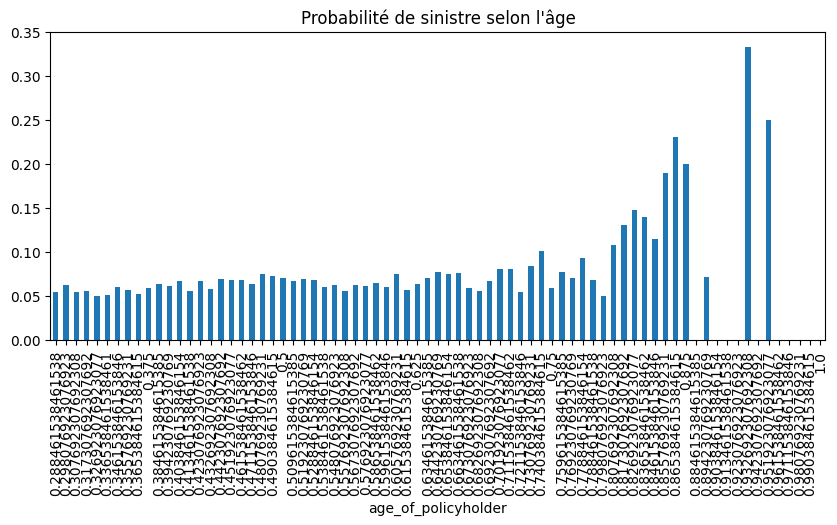

In [40]:
from matplotlib import pyplot as plt
p_by_age = data.groupby('age_of_policyholder')['is_claim'].mean()
p_by_age.plot(kind='bar', figsize=(10,4))
plt.title("Probabilité de sinistre selon l'âge")
plt.show()



Le risque de sinistre varie selon la valeur normalisée de l’âge. Certaines tranches (plus élevées ou plus basses) présentent une probabilité légèrement différente.

### ➡️Simulation de Monte Carlo

Je vais maintenant simuler un portefeuille de clients en utilisant la probabilité estimée.
Chaque client est modélisé par une variable de Bernoulli de paramètre 𝑝.

In [ ]:
import numpy as np
N = 10000  # nombre de clients
sim_claims = np.random.binomial(1, p_hat, N)
sim_claims.mean()

np.float64(0.065)

In [50]:
costs = np.array([500, 1500, 3000, 8000, 15000])


N_sim = 5000

results = []

for _ in range(N_sim):
    claims = np.random.binomial(1, p_hat, N)
    total_cost = np.sum(np.random.choice(costs, size=claims.sum(), replace=True))
    results.append(total_cost)
results = np.array(results)
print(results)

[3394000 3462500 3794000 ... 3635500 3640500 3182500]


In [51]:
print("Coût moyen :", results.mean())
print("Coût médian :", np.median(results))
print("95e percentile :", np.percentile(results, 95))


Coût moyen : 3582469.0
Coût médian : 3581750.0
95e percentile : 3906525.0


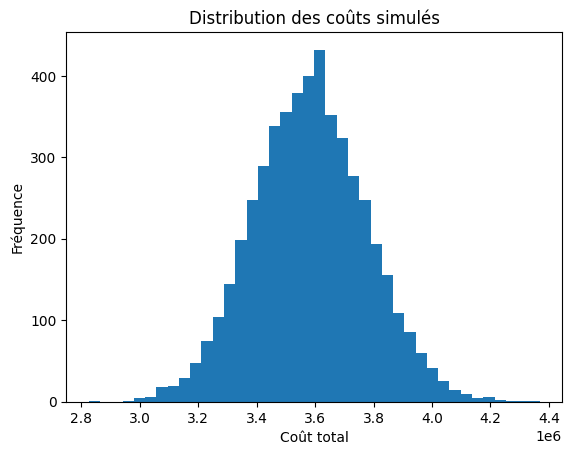

In [52]:
plt.hist(results, bins=40)
plt.title("Distribution des coûts simulés")
plt.xlabel("Coût total")
plt.ylabel("Fréquence")
plt.show()


### ➡️ Sum up de l'analyse

La probabilité d’un sinistre dans le dataset est d’environ 6,4 %, ce qui revient à dire que 6 à 7 clients sur 100 déclarent un sinistre.
Pour comprendre l’impact financier global, j’ai simulé plusieurs milliers d’années possibles pour un portefeuille de 10 000 clients.

Les résultats tournent autour de 3,58 M€ en moyenne, avec des scénarios plus élevés autour de 3,9 M€ (95e percentile).
La distribution obtenue est assez régulière, ce qui montre que, même si les sinistres sont rares, leur coût total reste relativement prévisible à grande échelle.

En résumé : faible fréquence, montants cumulés importants, et une bonne visibilité sur le risque global.